# Normalization module
The normalization module of the SUIT toolbox calculates a deformation field that maps the cerebellum of an individual subject to the SUIT template, using the mask generated by the isolation module. The Python-version uses the ANTSPy package to perform the normalization and will be released with version 2.1. The deformation field can then be used to reslice functional and anatomical data into SUIT space.

This notebook shows more detailed usage and options for the normalization module. We assume you have produced an isolation mask (``<basename>_cerebellum_desg.nii.gz``) as described in the last step. 

In [8]:
# Import necessary packages
from nilearn import plotting as npl
import SUITPy as suit
import nibabel as nib
import matplotlib.pyplot as plt

## Basic usage 
In the simplest case, `normalize` function takes the T1-weight image and isolation mask (``<basename>_cerebellum_desg.nii.gz`` from `isolation` function) as two parameters: 


In [2]:
# This function normalizes a source image to the SUIT cerebellar template using a provided cerebellum mask.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 verbose = 1)

Normalizing sub-ex_T1w to /Users/jdiedrichsen/Python/SUITPy/SUITPy/templates/tpl-SUIT_T1w.nii.gz
Saving the normalized image into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials/sub-ex_T1w_space-SUIT.nii.gz
Saving deformation field into /Users/jdiedrichsen/Python/SUITPy/docs/source/tutorials/sub-ex_T1w_to-SUIT_mode-image_xfm.nii.gz


Results is a dictionary that contains the filenames of the saved files. 

By default, ``normalize`` saves two files: 

* The deformation field required to reslice images into SUIT space: ``<Basename>_to-SUIT_mode-image_xfm.nii.gz``
* The resliced and masked anatomical in SUIT space: ``<Basename>_space-SUIT.nii.gz``

## Checking the normalization
Even though normalization usually works well, it is useful to check the alignment: 

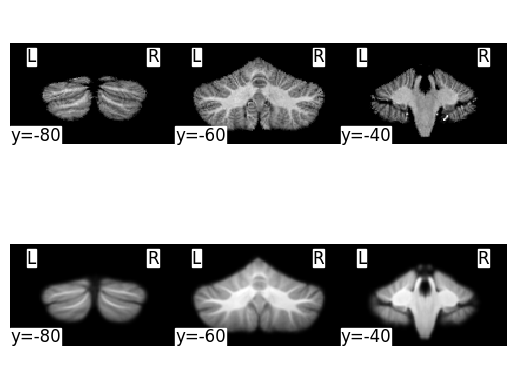

In [11]:
w_anat_img = nib.load(results['normalized_image'])
template_img = nib.load('../../../SUITPy/templates/tpl-SUIT_T1w.nii.gz')
plt.figure()
ax=plt.subplot(2,1,1)
npl.plot_img(w_anat_img,display_mode='y',cut_coords=[-80.0,-60.0,-40.0] , colorbar=False,axes=ax)
ax=plt.subplot(2,1,2)
npl.plot_img(template_img,display_mode='y',cut_coords=[-80.0,-60.0,-40.0] ,colorbar=False,axes=ax)

## Other  Template space
By default, the image is normalized to the SUIT cerebellar template.

If you want to use a different target space, simply specify the ``space`` parameter: `SUIT`, `MNI152NLin6AsymC` / 'MNI', `MNI152NLin2009cSymC` / 'MNISym'.
If you wish to use a custom cerebellum-only template that is not included in these options, you can provide a file directly using the ``template_file`` parameter: Optional path to a custom template file

In [ ]:
# This function normalizes a source image to the MNI152NLin2009cSymC space using a provided cerebellum mask.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 verbose = 1)

## Saving the Jacobian determinant

In [ ]:
# Set write_jacobian_determinant=True to save Jacobian determinant maps.
# The default output is the log-transformed geometric Jacobian determinant.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 write_jacobian_determinant=True,
                 verbose = 1)

## Saving the ants transform files
If you are familiar with ANTS and would like to work with the transformation files save in any format, you can use: 



In [ ]:
# Set write_ants_transform=True to save the ants transformation files.
results = suit.normalize(source_file = 'sub-ex_T1w.nii.gz',
                 mask_file = 'sub-ex_T1w_cerebellum_dseg.nii.gz',
                 space = 'MNISym',
                 write_ants_transform=True,
                 verbose = 1)

## Transforms between different template spaces 
Show how to transform data from SUIT to MNI or MNISym space 